03 — Linear models

Four linear models on the same 28 features and the same time-based split:
OLS as an unregularised baseline, Ridge for L2, Lasso for L1 (so we get implicit
feature selection), and ElasticNet to combine both. We sweep `alpha` and
`l1_ratio` with time-series-aware cross-validation inside `LassoCV` and
`ElasticNetCV` (`cv=3`, no shuffling) so the regulariser is picked without
touching the held-out validation set.

All four scale the features with `StandardScaler`. Zero-variance columns (e.g.
rare categoricals on small subsets) are dropped before scaling.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(__import__("pathlib").Path.cwd() / ".mplcache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.pipeline import prepare_data
from src.models import OLSModel, RidgeModel, LassoModel, ElasticNetModel
from src.viz.style import set_style, save_figure, PRIMARY, ACCENT, SUPPORT
from src.viz.result_plots import (
    plot_predicted_vs_actual, plot_residuals, plot_feature_importance,
)

set_style()
PLOT_DIR = Path("../results/plots/linear")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config("../configs/default.yaml")
prep = prepare_data(cfg, feature_set="engineered")
X_train, y_train = prep.train_full[prep.feature_cols], prep.target_log_train
X_val, y_val = prep.val_full[prep.feature_cols], prep.target_log_val
print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")


X_train: (5784969, 27) | X_val: (1975122, 27)


Fit all four

In [2]:
models = {
    "ols": OLSModel(),
    "ridge": RidgeModel(alphas=cfg.models.get("linear", {}).get("alphas",
                                                                 [0.001, 0.01, 0.1, 1.0, 10.0, 100.0])),
    "lasso": LassoModel(alphas=cfg.models.get("linear", {}).get("alphas"),
                        cv=3, random_state=cfg.random_state, max_iter=10_000),
    "elasticnet": ElasticNetModel(
        alphas=cfg.models.get("linear", {}).get("alphas"),
        l1_ratios=cfg.models.get("linear", {}).get("l1_ratios", [0.1, 0.3, 0.5, 0.7, 0.9]),
        cv=3, random_state=cfg.random_state, max_iter=10_000,
    ),
}

results = {}
for name, m in models.items():
    print(f"--- fitting {name} ---")
    preds_log, secs = m.fit_predict(X_train, y_train, X_val)
    pred_real = np.expm1(np.clip(preds_log, 0.0, 14.0))
    actual_real = np.expm1(np.clip(y_val, 0.0, 14.0))
    rmse = float(np.sqrt(np.mean((pred_real - actual_real) ** 2)))
    mae = float(np.mean(np.abs(pred_real - actual_real)))
    results[name] = {
        "rmse": rmse, "mae": mae,
        "train_seconds": secs,
        "preds": preds_log,
        "model": m,
    }
    print(f"  RMSE={rmse:.2f}  MAE={mae:.2f}  in {secs:.1f}s")


--- fitting ols ---


  RMSE=6428.25  MAE=676.57  in 3.7s
--- fitting ridge ---


  RMSE=6428.26  MAE=676.57  in 10.2s
--- fitting lasso ---


  RMSE=6557.71  MAE=677.02  in 8.4s
--- fitting elasticnet ---


  RMSE=6319.32  MAE=675.30  in 54.8s


In [3]:
summary = pd.DataFrame({
    name: [r["rmse"], r["mae"], r["train_seconds"]]
    for name, r in results.items()
}, index=["RMSE", "MAE", "train_s"]).T.sort_values("RMSE")
summary


,RMSE,MAE,train_s
elasticnet,6319.320963,675.297615,54.793282
ols,6428.253913,676.572220,3.708266
ridge,6428.257800,676.572233,10.225553
lasso,6557.714869,677.015329,8.429381


Predicted vs. actual

All four sit close to the diagonal in the bulk of the distribution but smear in
the tails — that is the point of comparing more flexible models in the next
notebooks.

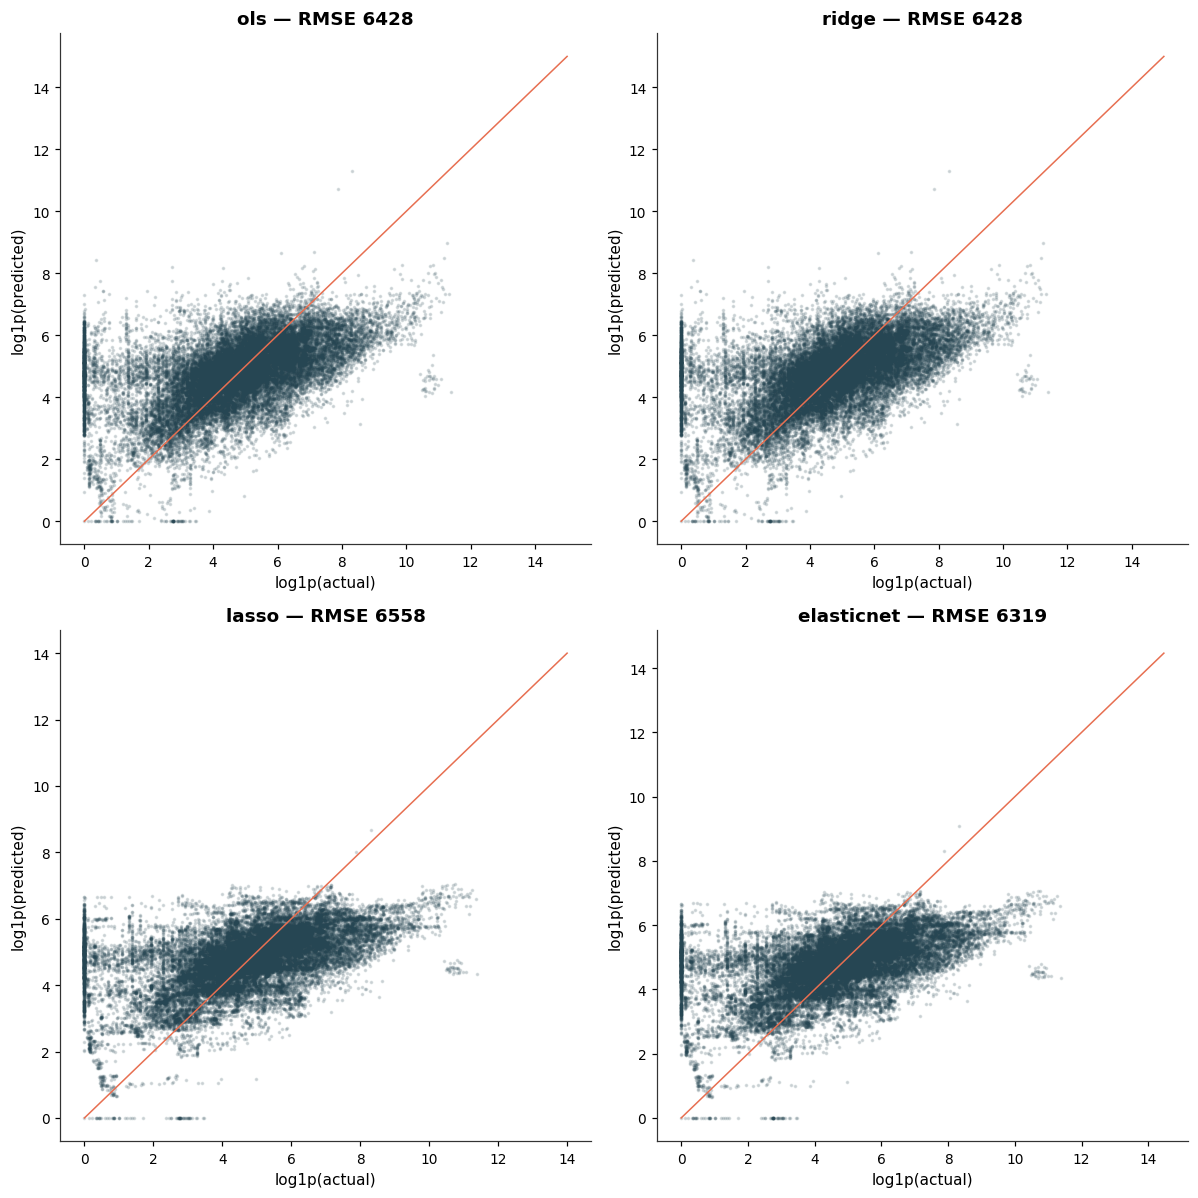

In [4]:
y_val_real = np.expm1(np.clip(y_val, 0.0, 14.0))
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    pr = np.expm1(np.clip(r["preds"], 0.0, 14.0))
    sample = np.random.default_rng(0).choice(len(pr), size=min(30_000, len(pr)), replace=False)
    ax.scatter(np.log1p(y_val_real[sample]), np.log1p(pr[sample]),
               s=2, alpha=0.15, color=PRIMARY)
    lo = 0; hi = max(np.log1p(y_val_real.max()), np.log1p(pr.max()) + 1)
    ax.plot([lo, hi], [lo, hi], color=ACCENT, linewidth=1)
    ax.set_xlabel("log1p(actual)")
    ax.set_ylabel("log1p(predicted)")
    ax.set_title(f"{name} — RMSE {r['rmse']:.0f}")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "pred_vs_actual_grid")
plt.show()


Coefficients

Lasso shrinks unhelpful coefficients to zero, which makes its non-zero set a
rough proxy for "what matters" once we control for everything else. The biggest
lever is almost always the lag/rolling family.

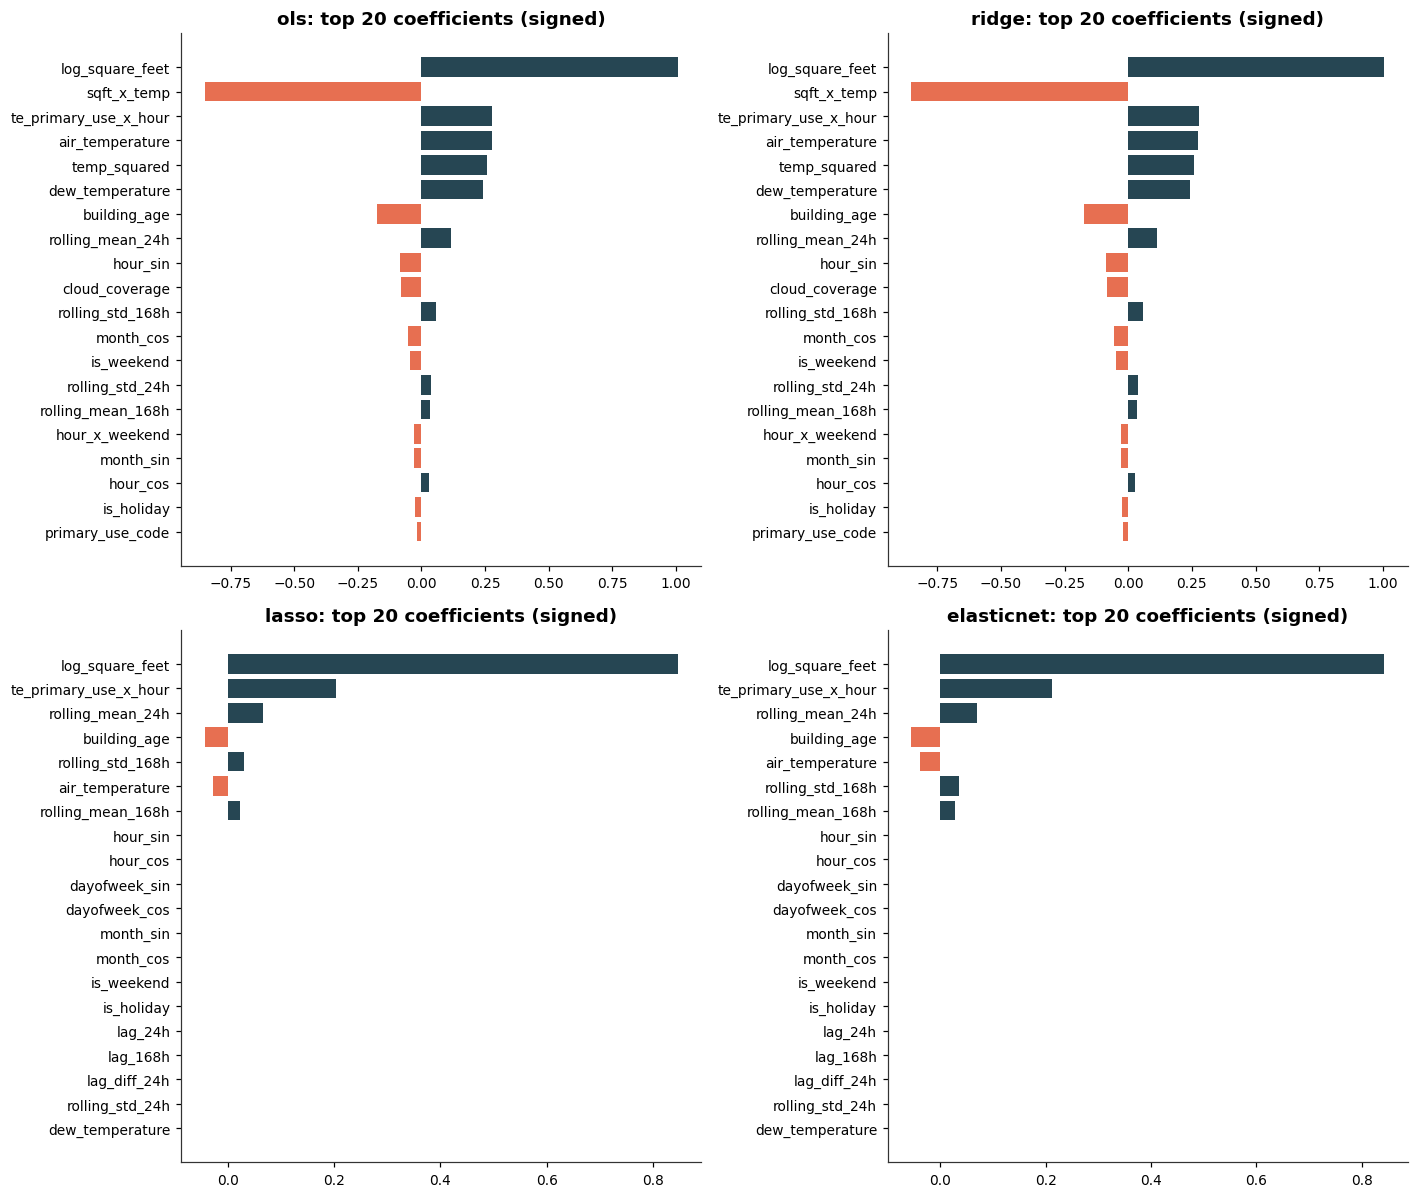

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    imp = r["model"].feature_importance() or {}
    if not imp:
        ax.text(0.5, 0.5, "no coefficients", ha="center")
        continue
    top = sorted(imp.items(), key=lambda kv: abs(kv[1]), reverse=True)[:20]
    names, vals = zip(*top)
    colors = [PRIMARY if v >= 0 else ACCENT for v in vals]
    ax.barh(list(reversed(names)), list(reversed(vals)), color=list(reversed(colors)))
    ax.set_title(f"{name}: top 20 coefficients (signed)")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "coefficients_grid")
plt.show()


Where do the linear models break

Per-meter and per-primary-use breakdowns. Hot water and steam meters are
typically where linear models lose the most ground.

In [6]:
val = prep.val_full.copy()
val["y_true"] = y_val_real
val["meter_name"] = val["meter"].map({0: "electricity", 1: "chilledwater",
                                       2: "steam", 3: "hotwater"})

per_meter = []
for name, r in results.items():
    pr = np.expm1(np.clip(r["preds"], 0.0, 14.0))
    val_tmp = val.copy(); val_tmp["y_pred"] = pr
    g = val_tmp.groupby("meter_name", observed=True).apply(
        lambda d: float(np.sqrt(np.mean((d["y_pred"] - d["y_true"]) ** 2)))
    )
    g.name = name
    per_meter.append(g)
per_meter_df = pd.concat(per_meter, axis=1).round(1)
per_meter_df


,ols,ridge,lasso,elasticnet
meter_name,,,,
chilledwater,3754.1,3754.1,3761.1,3760.8
electricity,247.5,247.5,238.7,238.0
hotwater,574.3,574.3,586.9,586.4
steam,16478.0,16478.0,16837.9,16169.9


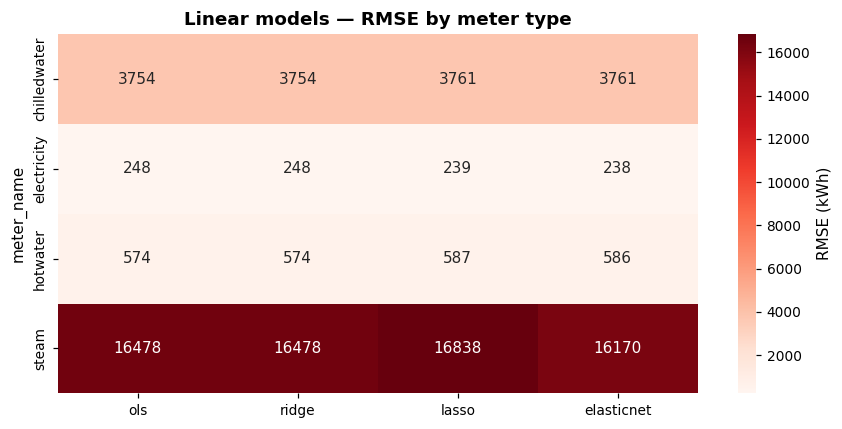

In [7]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(per_meter_df, annot=True, fmt=".0f", cmap="Reds", ax=ax,
            cbar_kws={"label": "RMSE (kWh)"})
ax.set_title("Linear models — RMSE by meter type")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "per_meter_rmse")
plt.show()


Saving

The full `train_all` script writes a JSON with all of these metrics plus the
per-group breakdowns. We also save the per-meter table here so the report can
pick it up directly.

In [8]:
PLOT_DIR.parent.parent.mkdir(parents=True, exist_ok=True)
out_dir = Path("../results/tables")
out_dir.mkdir(parents=True, exist_ok=True)
per_meter_df.to_csv(out_dir / "linear_per_meter_rmse.csv")
summary.to_csv(out_dir / "linear_summary.csv")
print(f"wrote linear_summary.csv and linear_per_meter_rmse.csv to {out_dir}")


wrote linear_summary.csv and linear_per_meter_rmse.csv to ../results/tables
